# EDA: транзакции под рекомендации

Разбираем сырые транзакции (party_rk, category_nm, merchant_type_code, merchant_nm, real_transaction_dttm): что в данных, какие проблемы для коллаборативной логики и почему в пайплайне пошли в сторону PCA + KMeans + cosine.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 5)

# источники данных: data/ или app/ (полный датасет в .gitignore), иначе сэмпл из notebooks/sample_data
BASE = Path('.').resolve()
if (BASE / 'notebooks' / 'sample_data').exists():
    pass  # уже в корне
elif (BASE / 'sample_data').exists():
    BASE = BASE.parent  # запуск из notebooks/
else:
    BASE = BASE if (BASE / 'data').exists() or (BASE / 'app').exists() else BASE

# Ищем данные: data/ → app/ → notebooks/sample_data/
search_dirs = [BASE / 'data', BASE / 'app', BASE, BASE / 'notebooks' / 'sample_data']
files = []
for d in search_dirs:
    if d.exists():
        files = sorted(d.glob('transaction_*.csv')) + sorted(d.glob('sample*.csv'))
        files = [f for f in files if f.suffix == '.csv'][:5]
        if files:
            break
if not files:
    raise FileNotFoundError(
        'Нет transaction_*.csv в data/, app/ или notebooks/sample_data/. '
        'Создай сэмпл: python notebooks/make_eda_sample.py'
    )

FIG_DIR = BASE / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Найдено файлов: {len(files)}')
for f in files:
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name}  ({size_mb:.1f} MB)')

Найдено файлов: 5
  transaction_101_new.csv  (189.8 MB)
  transaction_102_new.csv  (189.8 MB)
  transaction_103_new.csv  (189.7 MB)
  transaction_104_new.csv  (189.7 MB)
  transaction_105_new.csv  (189.7 MB)


## 1. Что в данных

Берём 500k строк из первого доступного файла — для EDA этого хватает. Смотрим типы, пропуски и кардинальности.

In [ ]:
# сэмпл: 500k строк из первого файла (достаточно для оценки распределений)
df_sample = pd.read_csv(files[0], nrows=500_000)
df_sample['real_transaction_dttm'] = pd.to_datetime(df_sample['real_transaction_dttm'], errors='coerce')

print('=== Размер (500k строк) ===')
print(df_sample.shape)
print('\n=== Типы и пропуски ===')
print(df_sample.dtypes)
print('\nПропуски (%):')
print((df_sample.isnull().mean() * 100).round(2))
print(f'\nВременной диапазон: {df_sample.real_transaction_dttm.min()} → {df_sample.real_transaction_dttm.max()}')
print(f'Уникальных пользователей: {df_sample.party_rk.nunique():,}')
print(f'Уникальных категорий: {df_sample.category_nm.nunique():,}')
print(f'Уникальных MCC: {df_sample.merchant_type_code.nunique():,}')
df_sample.head(3)

=== Размер (500k строк) ===
(500000, 6)

=== Типы и пропуски ===
real_transaction_dttm    datetime64[ns]
party_rk                         object
transaction_rk                   object
merchant_type_code                int64
merchant_nm                      object
category_nm                      object
dtype: object

Пропуски (%):
real_transaction_dttm    0.00
party_rk                 0.00
transaction_rk           0.00
merchant_type_code       0.00
merchant_nm              0.03
category_nm              6.65
dtype: float64

Временной диапазон: 2025-02-01 00:00:27 → 2025-02-28 23:59:17
Уникальных пользователей: 14,711
Уникальных категорий: 35
Уникальных MCC: 279


,real_transaction_dttm,party_rk,transaction_rk,merchant_type_code,merchant_nm,category_nm
0,2025-02-20 10:22:43,c207be682be7a9a33ad7a29436197ffcb6eb1b1e7ecc76...,b2efe974f6fc8d520cad9f722a2c914503b79f8a8c2df1...,5814,ZACEPI KOFE,Фаст Фуд
1,2025-02-13 11:17:30,74e7ac94a5794715b5af9123d78b26ef06caab5fa05071...,8501a22b0be66234b44580bea2a053f5c6ba71ce8bfd52...,4111,METRO,Транспорт
2,2025-02-07 21:39:44,9ddc4dcaaf0360365803ac666e856290dfe65ca3129b42...,c41b3c386a5f624481e23fa84c7b6fbeb9a7f71aa89a8e...,5499,KRASNOE&BELOE,Супермаркеты


## 2. Разреженность

У большинства пользователей мало транзакций, у многих — десятки. Прямо сравнивать по пересечению категорий почти бесполезно: совпадений мало. Ниже — распределение числа транзакций на юзера (хвост обрезан на 200 для читаемости графика).

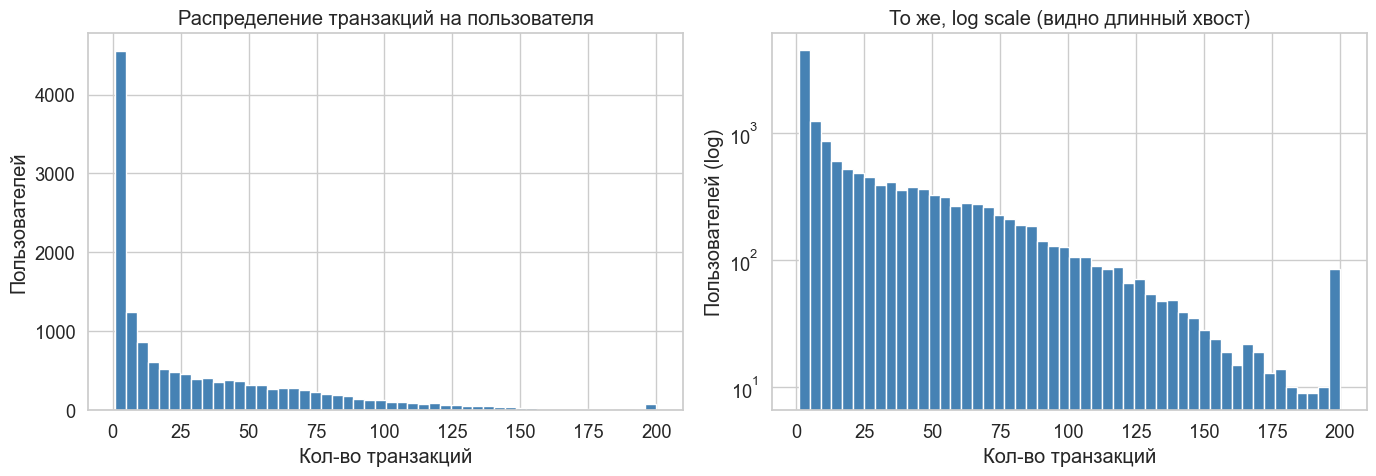

Медиана транзакций на пользователя: 17
Пользователей с < 5 транзакций: 4558 (31.0%) — отфильтрованы

→ Высокая разреженность: разные пользователи посещают разные места.
  Прямое пересечение категорий даёт ~52% пользователей с малой историей.
  Решение: TF-IDF нормализация + PCA для плотного представления.


In [ ]:
# число транзакций на юзера — основа для отсечки холодных и оценки разреженности
tx_per_user = df_sample.groupby('party_rk').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# обрезка хвоста на 200 для читаемости гистограммы
axes[0].hist(tx_per_user.clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение транзакций на пользователя')
axes[0].set_xlabel('Кол-во транзакций')
axes[0].set_ylabel('Пользователей')

axes[1].hist(tx_per_user.clip(upper=200), bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('То же, log scale (видно длинный хвост)')
axes[1].set_xlabel('Кол-во транзакций')
axes[1].set_ylabel('Пользователей (log)')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_tx_per_user.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Медиана транзакций на пользователя: {tx_per_user.median():.0f}')
print(f'С < 5 транзакций: {(tx_per_user < 5).sum()} ({(tx_per_user < 5).mean()*100:.1f}%) — в пайплайне таких отбрасываем')
print(f'\nИтог: разреженность высокая, пересечение по категориям слабый сигнал → в фичах используем TF-IDF и сжимаем через PCA.')

## 3. Длинный хвост категорий

Топ категорий по числу транзакций и по охвату пользователей. Супермаркеты, транспорт и т.п. есть у почти всех — по ним пользователей не различаем. Нужно давать больший вес редким категориям (IDF в пайплайне).

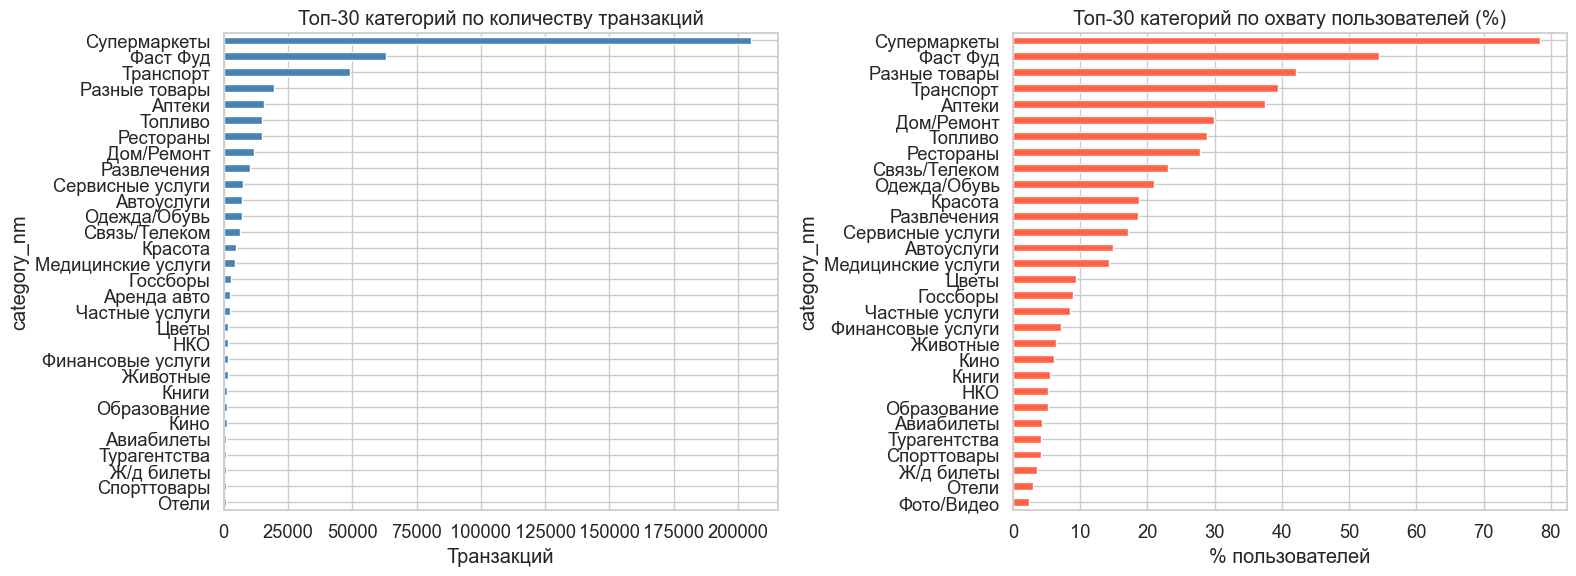

Топ-3 категории присутствуют у % пользователей:
  Супермаркеты: 78.4%
  Фаст Фуд: 54.4%
  Разные товары: 42.1%


In [ ]:
cat_freq = df_sample['category_nm'].value_counts()
top_cats = cat_freq.head(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_cats.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Топ-30 категорий по количеству транзакций')
axes[0].set_xlabel('Транзакций')

# охват категорий: доля юзеров с хотя бы одной транзакцией в категории
user_cat = df_sample.groupby('category_nm')['party_rk'].nunique()
coverage = (user_cat / df_sample['party_rk'].nunique() * 100).sort_values(ascending=False).head(30)
coverage.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].invert_yaxis()
axes[1].set_title('Топ-30 категорий по охвату пользователей (%)')
axes[1].set_xlabel('% пользователей')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_categories.png', dpi=100, bbox_inches='tight')
plt.show()

top3 = coverage.head(3)
print('Топ-3 по охвату (% юзеров с хотя бы одной транзакцией):')
for cat, pct in top3.items():
    print(f'  {cat}: {pct:.1f}%')
print('\nВывод: общие категории не различают людей → в фичах взвешиваем через IDF.')

## 4. Время как сигнал

Когда человек тратит (час, день недели) — сильный сигнал образа жизни. Утренний кофе, обед, вечерний шопинг, выходные. В пайплайне добавили фичи: час 0–23, день недели, доля выходных.

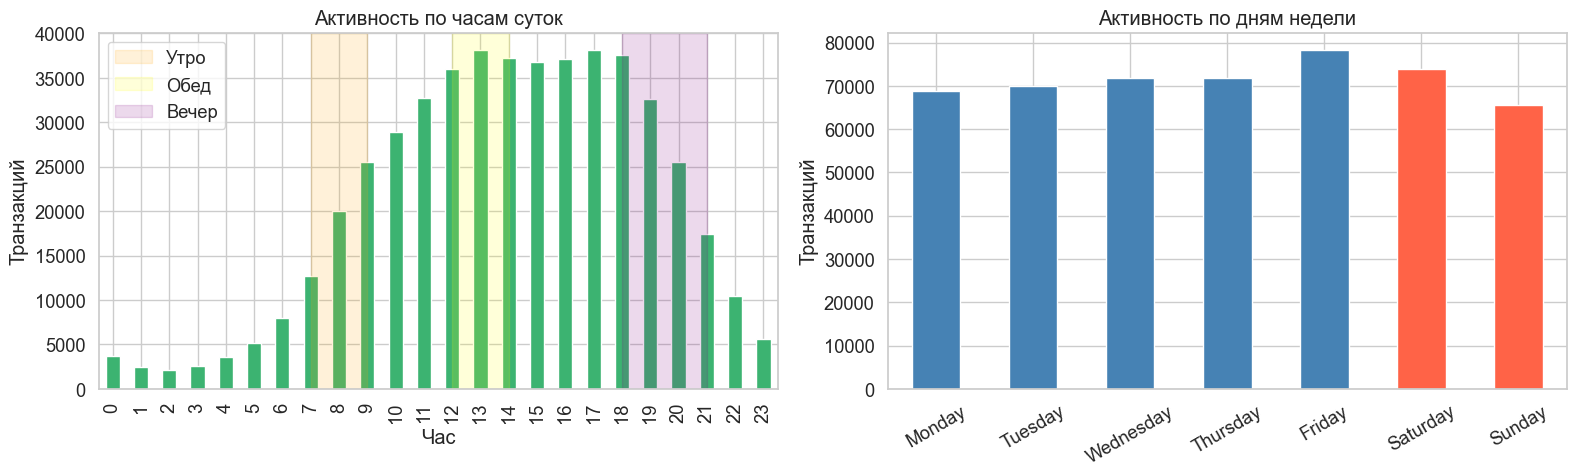

Доля транзакций в выходные: 27.9%


In [ ]:
# признаки времени: час и день недели
df_time = df_sample.dropna(subset=['real_transaction_dttm']).copy()
df_time['hour'] = df_time['real_transaction_dttm'].dt.hour
df_time['dow'] = df_time['real_transaction_dttm'].dt.dayofweek
df_time['dow_name'] = df_time['real_transaction_dttm'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_dist = df_time.groupby('hour').size()
hour_dist.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Активность по часам суток')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Транзакций')
axes[0].axvspan(7, 9, alpha=0.15, color='orange', label='Утро')
axes[0].axvspan(12, 14, alpha=0.15, color='yellow', label='Обед')
axes[0].axvspan(18, 21, alpha=0.15, color='purple', label='Вечер')
axes[0].legend()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_dist = df_time.groupby('dow_name').size().reindex(day_order)
colors = ['steelblue']*5 + ['tomato']*2
day_dist.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Активность по дням недели')
axes[1].set_xlabel('')
axes[1].set_ylabel('Транзакций')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_time_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

weekend_ratio = (df_time['dow'] >= 5).mean()
print(f'Доля транзакций в выходные: {weekend_ratio*100:.1f}%')
print('Паттерны по времени используем в фичах (hour, dow, weekend_ratio).')

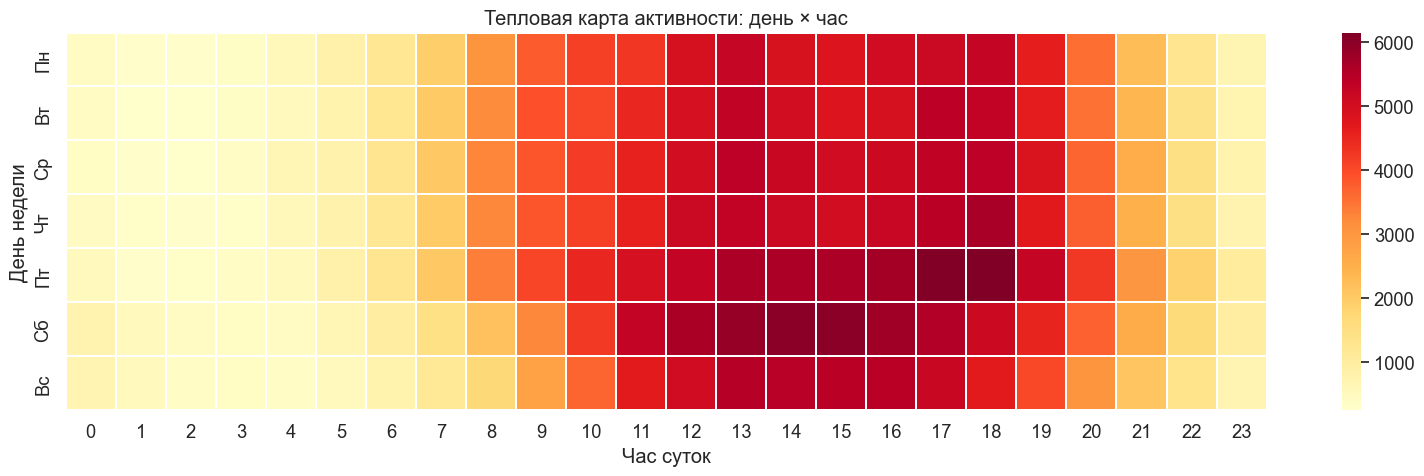

In [ ]:
# тепловая карта активности: день недели × час
heatmap_data = df_time.groupby(['dow', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, fmt='d')
plt.title('Тепловая карта активности: день × час')
plt.xlabel('Час суток')
plt.ylabel('День недели')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_heatmap_hour_dow.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. MCC-коды

Тип заведения (MCC) даёт более мелкую градацию, чем категория: один ресторан vs фастфуд, аптека vs клиника. В пайплайне берём топ-50 MCC по частоте как отдельные фичи.

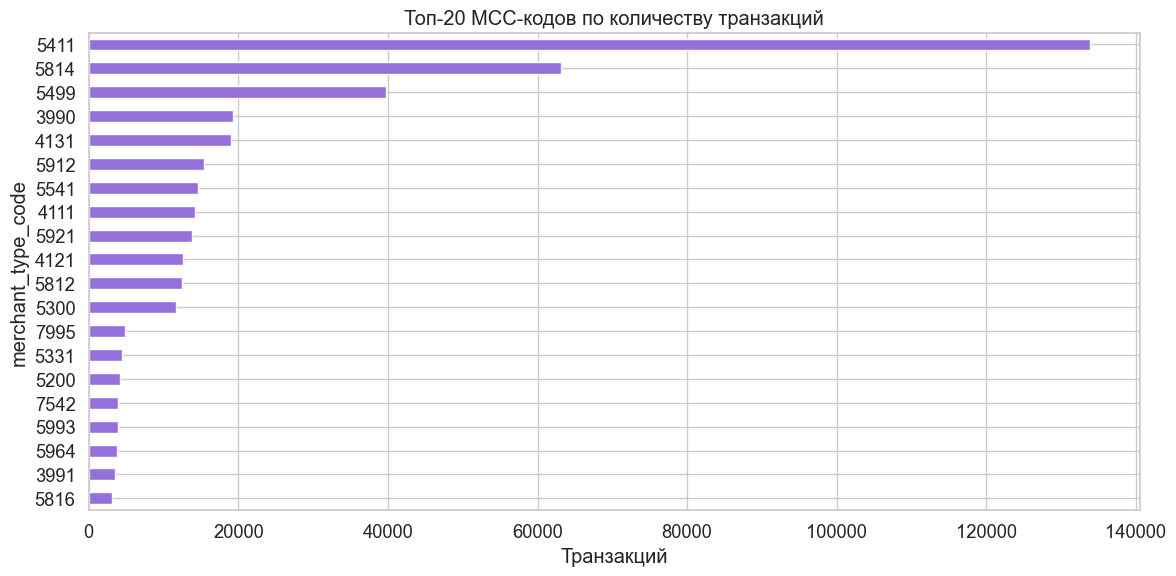

Уникальных MCC на пользователя: медиана=6, max=55

→ MCC-код точнее категории: отличает ресторан от фастфуда, аптеку от больницы.


In [ ]:
mcc_freq = df_sample['merchant_type_code'].value_counts().head(20)

plt.figure(figsize=(12, 6))
mcc_freq.plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Топ-20 MCC-кодов по количеству транзакций')
plt.xlabel('Транзакций')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_mcc_codes.png', dpi=100, bbox_inches='tight')
plt.show()

mcc_per_user = df_sample.groupby('party_rk')['merchant_type_code'].nunique()
print(f'MCC на юзера: медиана {mcc_per_user.median():.0f}, max {mcc_per_user.max()}')
print('В фичах используем топ-50 MCC.')


## 6. Зачем PCA

Признаков получается много (категории + MCC + время + токены мерчантов). Cosine в такой размерности шумит, плюс проклятие размерности. PCA режет до 50 компонент — оставляем главные направления, с ними уже можно стабильно считать похожесть.

In [ ]:
# размерность признаков в пайплайне
n_cats = df_sample['category_nm'].nunique()
n_mcc = df_sample['merchant_type_code'].nunique()
n_temporal = 24 + 7 + 2
n_tokens = 200
total_raw = n_cats + min(n_mcc, 50) + n_temporal + n_tokens + 1

print('Признаков до PCA: категории + 50 MCC + время + 200 токенов + tx_count ≈', total_raw)
print('После PCA: 50 компонент. Cosine считаем уже в 50D — меньше шума и стабильнее.')

=== Количество признаков до PCA ===
  cat_*      : ~35 (категории покупок)
  mcc_*      : 50 (топ MCC-кодов)
  temporal_* : 33 (часы + дни + паттерны)
  tok_*      : 200 (топ токенов мерчантов)
  tx_count   : 1
  ИТОГО      : ~319 признаков

=== После PCA ===
  50 компонент объясняют основную дисперсию
  Сжатие: 319D → 50D (6x)

→ Без PCA: cosine similarity в 300D пространстве работает,
  но страдает от проклятия размерности и шума редких признаков.
  PCA убирает шум, оставляет главные направления схожести.


## 8. Качество кластеров (опционально)

Если уже есть обученный `user_clusters.parquet`, можно глянуть размеры кластеров и что cosine внутри кластера выше, чем между — значит группировка осмысленная.

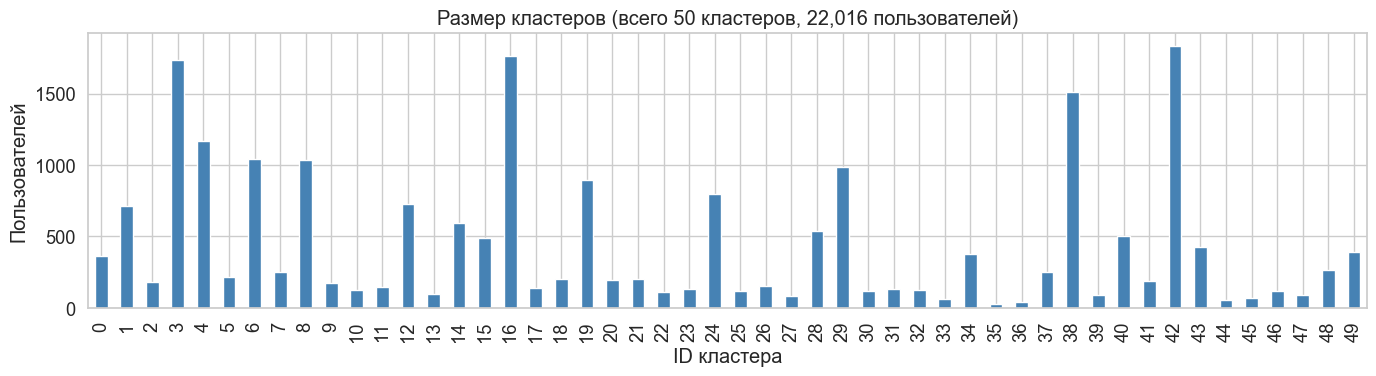

Пользователей в индексе: 22,016
Кластеров: 50
Средний размер кластера: 440.3
Мин/макс: 27 / 1836


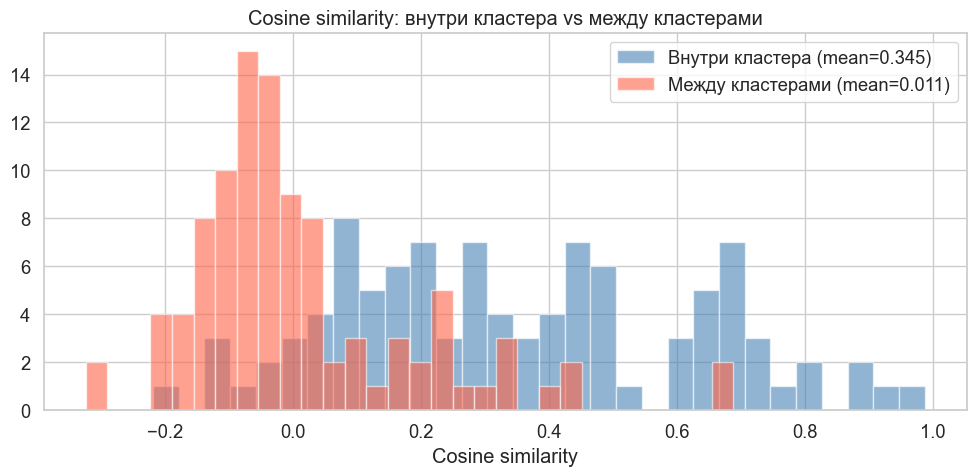

In [ ]:
# путь к артефакту (создаётся train_pca_kmeans + seed_clusters)
CLUSTERS_PATH = BASE / 'models' / 'user_clusters.parquet'

if CLUSTERS_PATH.exists():
    df_cl = pd.read_parquet(CLUSTERS_PATH)
    pca_cols = [c for c in df_cl.columns if c.startswith('pca_')]

    # распределение размеров кластеров
    cluster_sizes = df_cl['cluster'].value_counts().sort_index()
    plt.figure(figsize=(14, 4))
    cluster_sizes.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title(f'Размер кластеров (всего {df_cl["cluster"].nunique()} кластеров, {len(df_cl):,} пользователей)')
    plt.xlabel('ID кластера')
    plt.ylabel('Пользователей')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '06_cluster_sizes.png', dpi=100, bbox_inches='tight')
    plt.show()

    print(f'Пользователей в индексе: {len(df_cl):,}')
    print(f'Кластеров: {df_cl["cluster"].nunique()}')
    print(f'Средний размер кластера: {cluster_sizes.mean():.1f}')
    print(f'Мин/макс: {cluster_sizes.min()} / {cluster_sizes.max()}')

    # сравнение cosine внутри кластера и между кластерами
    vecs = df_cl[pca_cols].values.astype(np.float32)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    vecs_norm = vecs / norms

    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(df_cl), size=min(300, len(df_cl)), replace=False)
    clusters = df_cl['cluster'].values

    intra, inter = [], []
    for i in sample_idx[:100]:
        same = np.where(clusters == clusters[i])[0]
        diff = np.where(clusters != clusters[i])[0]
        if len(same) > 1:
            j = rng.choice(same[same != i])
            intra.append(float(vecs_norm[i] @ vecs_norm[j]))
        if len(diff) > 0:
            j = rng.choice(diff)
            inter.append(float(vecs_norm[i] @ vecs_norm[j]))

    plt.figure(figsize=(10, 5))
    plt.hist(intra, bins=30, alpha=0.6, label=f'Внутри кластера (mean={np.mean(intra):.3f})', color='steelblue')
    plt.hist(inter, bins=30, alpha=0.6, label=f'Между кластерами (mean={np.mean(inter):.3f})', color='tomato')
    plt.title('Cosine similarity: внутри кластера vs между кластерами')
    plt.xlabel('Cosine similarity')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '07_cosine_intra_vs_inter.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Внутри кластера cosine выше, чем между — группировка осмысленная.')
else:
    print(f'Нет {CLUSTERS_PATH}. Сначала обучить пайплайн и seed_clusters.')